# Prática — Módulo 10: RF e GBT em Análise Preditiva

In [1]:
# Importações
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# Carregar dataset
df = pd.read_csv("/content/renda-emprestimo-risco.csv", sep = ";")
df

,index,idade,renda_anual,tempo_emprego,estado_civil,valor_solicitado,risco
0,0,56,36453.68,3,solteiro,21452.64,alto
1,1,46,67929.83,15,casado,33282.52,alto
2,2,32,68234.96,6,solteiro,34204.77,alto
3,3,25,68049.49,12,solteiro,39411.72,alto
4,4,38,35318.77,9,casado,16724.26,alto
...,...,...,...,...,...,...,...
195,195,23,63339.27,19,casado,29406.02,alto
196,196,49,24000.00,4,solteiro,9717.64,medio
197,197,21,41566.46,1,casado,19295.04,alto
198,198,28,65350.89,5,casado,29559.83,medio


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             200 non-null    int64  
 1   idade             200 non-null    int64  
 2   renda_anual       200 non-null    float64
 3   tempo_emprego     200 non-null    int64  
 4   estado_civil      200 non-null    object 
 5   valor_solicitado  200 non-null    float64
 6   risco             200 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 11.1+ KB


In [4]:
df = df.drop(columns=["index"])

In [5]:
# Codificando única variável categórica
df["estado_civil"] = df["estado_civil"].map({
    "solteiro": 0,
    "casado": 1
})

df

,idade,renda_anual,tempo_emprego,estado_civil,valor_solicitado,risco
0,56,36453.68,3,0,21452.64,alto
1,46,67929.83,15,1,33282.52,alto
2,32,68234.96,6,0,34204.77,alto
3,25,68049.49,12,0,39411.72,alto
4,38,35318.77,9,1,16724.26,alto
...,...,...,...,...,...,...
195,23,63339.27,19,1,29406.02,alto
196,49,24000.00,4,0,9717.64,medio
197,21,41566.46,1,1,19295.04,alto
198,28,65350.89,5,1,29559.83,medio


In [6]:
df.describe()

,idade,renda_anual,tempo_emprego,estado_civil,valor_solicitado
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,38.665000,50644.286550,9.175000,0.490000,19842.384600
std,12.604648,14006.058244,5.848538,0.501154,7835.562524
min,18.000000,24000.000000,0.000000,0.000000,5310.920000
25%,27.750000,40576.497500,4.000000,0.000000,14125.277500
50%,40.000000,49833.450000,9.000000,0.000000,18436.455000
75%,49.250000,61321.517500,14.000000,1.000000,25829.330000
max,59.000000,87375.680000,19.000000,1.000000,41335.440000


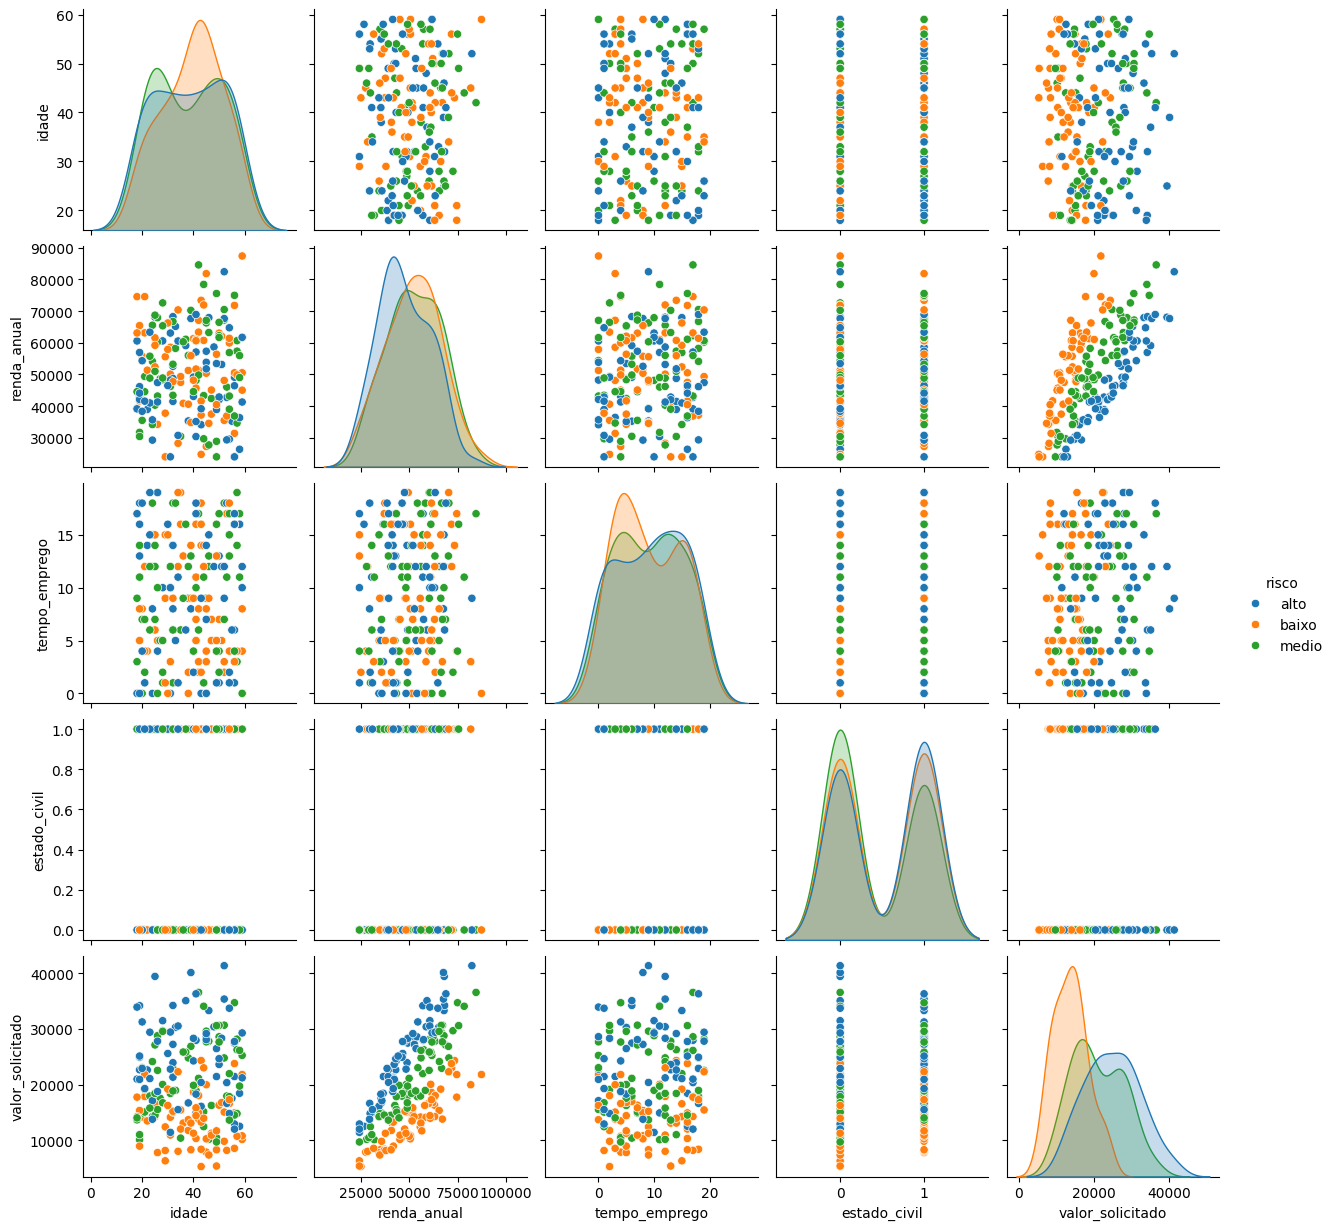

In [7]:
# Analisando correlação e separabilidade linear
sns.pairplot(df, hue="risco")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# Separando as variáveis explicativas e a variável alvo
X = df[["idade", "renda_anual", "tempo_emprego", "estado_civil", "valor_solicitado"]]
y = df["risco"]

# Separando dados de treino e de teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest

In [9]:
# Treinando uma árvore de decisão
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [10]:
# Avaliando o erro do modelo
from sklearn.metrics import precision_score, recall_score, f1_score

print("accuracy:", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred, average="macro"))
print("recall:", recall_score(y_test, y_pred, average="macro"))
print("f1:", f1_score(y_test, y_pred, average="macro"))

accuracy: 0.775
precision: 0.7939691027926322
recall: 0.7738095238095237
f1: 0.7794799870536195


## Pergunta
1. Por que o Random Forest não melhorou significativamente o desempenho em relação à árvore isolada?    
Resp.: Porque ele reduz variância, mas não cria informação nova. Como os dados já limitam a separação, o ganho é pequeno.

2. Aumentar o número de árvores sempre melhora o desempenho do modelo?    
Resp.: Não. Aumenta a estabilidade, mas não supera limitações impostas pelas variáveis.

3. Ao utilizar uma Random Forest, uma nova instância é submetida a uma única árvore ou a todas as árvores do modelo?

4. Como as previsões individuais são combinadas para gerar o resultado final?

# Gradient Boosting

In [11]:
# Treinando uma árvore de decisão com parâmetros default
from sklearn.ensemble import GradientBoostingClassifier

gbt_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbt_model.fit(X_train, y_train)
y_pred = gbt_model.predict(X_test)

In [12]:
# Avaliando o erro do modelo
from sklearn.metrics import precision_score, recall_score, f1_score

print("accuracy:", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred, average="macro"))
print("recall:", recall_score(y_test, y_pred, average="macro"))
print("f1:", f1_score(y_test, y_pred, average="macro"))

accuracy: 0.75
precision: 0.75
recall: 0.753968253968254
f1: 0.7495726495726496


### Pergunta
3. Por que o Gradient Boosting também não apresentou melhora relevante?   
Resp.: Porque há pouco erro estruturado para ser corrigido, limitando o aprendizado incremental.

4. O Gradient Boosting sempre supera o Random Forest?   
Resp.: Não. Depende da presença de padrões residuais nos dados; sem isso, o ganho é limitado.